# Chocolate Bar Ratings - (Data Cleaning & EDA)

Jacqueline Molina | June 2026

This dataset contains expert ratings of over 1,700 individual chocolate bars, along with information on their regional origin, percentage of cocoa, the variety of chocolate bean used and where the beans were grown.

<b>Flavors of Cacao Rating System:</b>
<ul>
<li>5 = Elite (Transcending beyond the ordinary limits)</li>
<li>4 = Premium (Superior flavor development, character and style)</li>
<li>3 = Satisfactory(3.0) to praiseworthy(3.75) (well made with special qualities)</li>
<li>2 = Disappointing (Passable but contains at least one significant flaw)</li>
<li>1 = Unpleasant (mostly unpalatable)</li>
</ul>

<b>Flavor</b> is the most important component of the Flavors of Cacao ratings. Diversity, balance, intensity and purity of flavors are all considered. It is possible for a straight forward single note chocolate to rate as high as a complex flavor profile that changes throughout. Genetics, terroir, post harvest techniques, processing and storage can all be discussed when considering the flavor component.

<b>Texture</b> has a great impact on the overall experience and it is also possible for texture related issues to impact flavor. It is a good way to evaluate the makers vision, attention to detail and level of proficiency.

<b>Aftermelt</b> is the experience after the chocolate has melted. Higher quality chocolate will linger and be long lasting and enjoyable. Since the aftermelt is the last impression you get from the chocolate, it receives equal importance in the overall rating.

<b>Overall Opinion</b> is really where the ratings reflect a subjective opinion. Ideally it is my evaluation of whether or not the components above worked together and an opinion on the flavor development, character and style. It is also here where each chocolate can usually be summarized by the most prominent impressions that you would remember about each chocolate.

## Initial Data Analysis

In [1128]:
## importing all needed libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [1129]:
# read data in to notebook
url = 'flavors_of_cacao.csv'
df = pd.read_csv(url)
df.head()

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru


In [1130]:
df.shape

(1795, 9)

In [1131]:
df.describe()

,REF,Review\nDate,Rating
count,1795.000000,1795.000000,1795.000000
mean,1035.904735,2012.325348,3.185933
std,552.886365,2.927210,0.478062
min,5.000000,2006.000000,1.000000
25%,576.000000,2010.000000,2.875000
50%,1069.000000,2013.000000,3.250000
75%,1502.000000,2015.000000,3.500000
max,1952.000000,2017.000000,5.000000


In [1132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Company 
(Maker-if known)         1795 non-null   object 
 1   Specific Bean Origin
or Bar Name  1795 non-null   object 
 2   REF                               1795 non-null   int64  
 3   Review
Date                       1795 non-null   int64  
 4   Cocoa
Percent                     1795 non-null   object 
 5   Company
Location                  1795 non-null   object 
 6   Rating                            1795 non-null   float64
 7   Bean
Type                         1794 non-null   object 
 8   Broad Bean
Origin                 1794 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 126.3+ KB


In [1133]:
## Checking all 
missing_data = df.isnull()
for col in missing_data.columns.values.tolist():
    print(missing_data[col].value_counts())
    print('')

Company \n(Maker-if known)
False    1795
Name: count, dtype: int64

Specific Bean Origin\nor Bar Name
False    1795
Name: count, dtype: int64

REF
False    1795
Name: count, dtype: int64

Review\nDate
False    1795
Name: count, dtype: int64

Cocoa\nPercent
False    1795
Name: count, dtype: int64

Company\nLocation
False    1795
Name: count, dtype: int64

Rating
False    1795
Name: count, dtype: int64

Bean\nType
False    1794
True        1
Name: count, dtype: int64

Broad Bean\nOrigin
False    1794
True        1
Name: count, dtype: int64



## Cleaning Dataset

In [1134]:
columnNames = ['Company', 'Bean Origin', 'REF', 'Review Date','Cocoa Percentage', 'Company Location', 'Rating', 'Bean Type', 'Broad Bean Origin']
df.columns = columnNames
df.head()

,Company,Bean Origin,REF,Review Date,Cocoa Percentage,Company Location,Rating,Bean Type,Broad Bean Origin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru


In [1135]:
df['Broad Bean Origin'].value_counts()

Broad Bean Origin
Venezuela                214
Ecuador                  193
Peru                     165
Madagascar               145
Dominican Republic       141
                        ... 
Peru, Belize               1
Peru, Mad., Dom. Rep.      1
PNG, Vanuatu, Mad          1
Trinidad, Ecuador          1
Venezuela, Carribean       1
Name: count, Length: 100, dtype: int64

In [1136]:
df['Bean Type'].value_counts()

Bean Type
                            887
Trinitario                  419
Criollo                     153
Forastero                    87
Forastero (Nacional)         52
Blend                        41
Criollo, Trinitario          39
Forastero (Arriba)           37
Criollo (Porcelana)          10
Trinitario, Criollo           9
Forastero (Parazinho)         8
Forastero (Arriba) ASS        6
Nacional (Arriba)             3
Matina                        3
EET                           3
Beniano                       3
Criollo (Ocumare 61)          2
Trinitario, Forastero         2
Trinitario (85% Criollo)      2
Forastero (Catongo)           2
Criollo, Forastero            2
Amazon, ICS                   2
Criollo (Amarru)              2
Amazon mix                    2
Nacional                      2
Criollo (Ocumare)             1
Criollo (Ocumare 67)          1
Trinitario, TCGA              1
Trinitario (Amelonado)        1
Trinitario, Nacional          1
Forastero (Amelonado)         

In [1137]:
df['Bean Origin'].value_counts()

Bean Origin
Madagascar                        57
Peru                              45
Ecuador                           42
Dominican Republic                37
Venezuela                         21
                                  ..
Conacado, #213, DR, -C             1
Sambirano Valley, #215, MR, MC     1
Chuao, #218, MR, MC                1
Chuao, #217, DR, MC                1
Brazil, Mitzi Blue                 1
Name: count, Length: 1039, dtype: int64

### Dropping any Null Values

In [1138]:
df = df.dropna(subset=['Bean Origin','Bean Type','Broad Bean Origin'])
missing_data = df.isnull()

### Cleaning Bean Origin (Reducing Varieties)

In [1139]:
df['Bean Origin'].value_counts()

Bean Origin
Madagascar                        56
Peru                              45
Ecuador                           42
Dominican Republic                37
Venezuela                         21
                                  ..
Conacado, #213, DR, -C             1
Sambirano Valley, #215, MR, MC     1
Chuao, #218, MR, MC                1
Chuao, #217, DR, MC                1
Brazil, Mitzi Blue                 1
Name: count, Length: 1038, dtype: int64

In [1140]:
df['Bean Origin'].value_counts().sort_index().count()

np.int64(1038)

In [1141]:
df['Bean Origin Simple'] = df['Bean Origin'].copy()

def simpleText(text):
    if ',' in text:
        text = text.split(',')[0]
    return text.strip()

df['Bean Origin Simple'] = df['Bean Origin Simple'].apply(simpleText)

In [1142]:
df['Bean Origin Simple'] = df['Bean Origin Simple'].replace({
    'Zorzal Reserva w/ Charles Kerchner': 'Zorzal Reserva',
    'Xocunusco': 'Xoconusco',
    'Winak Coop': 'Winak',
    'Wild Bolivia': 'Wild Bolivian',
    'Wild Beni': 'Wild Beniano',
    'Wampusirpi Region': 'Wampusirpi',
    'Venzuela': 'Venezuela',
    'Venezuela; Barinos': 'Venezuela',
    'Vale do Juliana E.': 'Vale do Juliana',
    'Upala w/ nibs': 'Upala',
    'Tumbes Coop': 'Tumbes',
    'Trinidad-Tobago': 'Trinidad',
    'Trinidad & Tobago': 'Trinidad',
    'Tome Acu E.': 'Tome Acu',
    'Terreiro Velho P. w/ sugar crystals': 'Terreiro Velho P.',
    '"heirloom"': 'hierloom',
    'Africa meets Latina': 'Africa',
    'Akesson P.': 'Akesson',
    'Akesson Estate': 'Akesson',
    'Akesson\'s': 'Akesson',
    'Akesson\'s E.': 'Akesson',
    'Akesson\'s Estate': 'Akesson',
    'Akessons Estate': 'Akesson',
    'Amazonas Frucht':'Amazonas',
    'Amazonas w/ nibs': 'Amazonas',
    'Amazonia': 'Amazonas',
    'Ambolikapiky P.': 'Ambolikapiky',
    'Ambolikapkly P.': 'Ambolikapiky',
    'Ba Ria Vung Tau Province': 'Ba Ria',
    'Bahia Black': 'Bahia',
    'Bahia Brazil': 'Bahia',
    'Bahia Superior': 'Bahia',
    'Tan Phu Dong Island': 'Tan Phu Dong',
    'TCHOPro 68':'TCHOPro',
    'TCHOPro 60.5': 'TCHOPro',
    'Sur del Lago Classificado': 'Sur del Lago',
    'South America and Africa': 'South America',
    'Somia Plantation': 'Somia',
    'Solomon Island w/ nibs': 'Solomon Island',
    'Sisa\'s Secret/ original micro':'Sisa',
    'Sisa 36hr/ W. F. blend prototype': 'Sisa',
    'Selva Maya': 'Selva',
    'Satipo region': 'Satipo',
    'Satipo Pangoa region': 'Satipo',
    'Sao Tome & Principe': 'Sao Tome',
    'San Juan de Cheni': 'San Juan',
    'San Juan Estate': 'San Juan',
    'San Jose del Tambo':'San Jose',
    'Sambirano Valley': 'Sambirano',
    'Sambirano 2006': 'Sambirano',
    'Rio Tuma': 'Rio',
    'Rio Peripa H.': 'Rio',
    'Rio Eni': 'Rio',
    'Rio Dulce': 'Rio',
    'Rio Caribe Superior': 'Rio',
    'Rio Caribe': 'Rio',
    'Rio Arriba': 'Rio',
    'Piura Select':'Piura',
    'Piura Blanco':'Piura',
    'Pinchincha':'Pichincha',
    'Peruvian Amazon': 'Peru',
    'Peruvian': 'Peru',
    'Peru- Ecuador': 'Peru',
    'Peru Brutus': 'Peru',
    'Peru + nibs': 'Peru',
    'Patanemo Vil.': 'Patanemo',
    'Selvagem': 'Selva',
    'Papaua New Guinea': 'Papua New Guinea',
    'Papua Kerafat': 'Papua New Guinea',
    'PNG':'Papua New Guinea',
    'Papua': 'Papua New Guinea',
    'Palos Blancos + nibs': 'Palo Blanco',
    'Palos Blancos': 'Palo Blanco',
    'Palo Blanco w/ panela': 'Palo Blanco',
    'Ocumare de la Costa': 'Ocumare',
    'Ocumare 77':'Ocumare',
    'Ocumare 67': 'Ocumare',
    'Ocumare 61':'Ocumare',
    'O\'payo':'Opayo',
    'O\'ahu': 'Oahu',
    'O\'Payo': 'Opayo',
    'Noir Infini': 'Noir',
    'Nicaraqua': 'Nicaragua',
    'Nicalizo': 'Nicaliso',
    'Monte Alegre (Itacare)':'Monte Alegre',
    'Moho Valley': 'Moho',
    'Moho River Valley': 'Moho',
    'Moho River' :'Moho',
    'Millot Plantation':'Millot',
    'Millot P.':'Millot',
    'Mekong Delta & Dong Nai': 'Mekong Delta',
    'Maya Mtn.': 'Maya',
    'Maya Mtn': 'Maya',
    'Maya Mountain w/ nibs':'Maya',
    'Maya Mountain': 'Maya',
    'Maya Belize':'Maya',
    'Maranon Canyon':'Maranon',
    'Maracaibo Clasificado': 'Maracaibo',
    'Marabel Farms': 'Mara',
    'Malekula P.': 'Malekula',
    'Malekula Island': 'Malekula',
    'Maleku':'Malekula',
    'Madagascar w/ nibs':'Madagascar',
    'Madagared': 'Madagascar',
    'Macuare; Miranda; Chloe formula': 'Macuare',
    'Taino Secret': 'Tainori',
    'Le Noir Extra Amer': 'Le Noir Amer',
    'Lachua w/ maple sugar': 'Lachua',
    'Lachua w/ cane sugar': 'Lachua',
    'La Red de Guanconejo': 'La Red',
    'Kulili P.': 'Kulili',
    'Kulili Estate': 'Kulili',
    'Kokoa Kamili Coop': 'Kokoa Kamili',
    'Kilombero Valley': 'Kilombero',
    'Kaua\'i': 'Kauai',
    'Kaua\'I': 'Kauai',
    'Kakao Kamili': 'Kakao Kamili',
    'Jamaica a l\'ancienne': 'Jamaica',
    'Jamaique': 'Jamaica',
    'Indianer': 'India',
    'India (south)': 'India',
    'Houseblend': 'House Blend',
    'Hispaniola w/ nibs': 'Hispaniola',
    'Hawaiian Crown': 'Hawaii',
    'Hawaiian': 'Hawaii',
    'Hawai\'i': 'Hawaii',
    'Hamakua Coast': 'Hamakua',
    'Haleiwa E': 'Haleiwa',
    'Grand Cru Ghana': 'Grand Cru',
    'Grand Cru Ecuador': 'Grand Cru',
    'Grand Cru Dominican Republic': 'Grand Cru',
    'Grand Cru Blend No.1': 'Grand Cru',
    'Gran Couva 2005 P.': 'Gran Couva',
    'Ghana prototype': 'Ghana',
    'Ghana Puristique': 'Ghana',
    'Fazenda Sempre Firme P.': 'Fazenda',
    'Fazenda Sempre Firme':'Fazenda',
    'Fazenda Leolinda':'Fazenda',
    'Fazenda Camboa': 'Fazenda',
    'Elvesia P.': 'Elvesia',
    'Ecuador Puristique': 'Ecuador',
    'Duo- Gran Couva & Camino Verde': 'Gran Couva',
    'Duarte Province': 'Duarte',
    'Dominican Republicm': 'Dominican Republic',
    'Dominican Republic-Organic': 'Dominican Republic',
    'Dominican Republic w/ nibs': 'Dominican Republic',
    'Dominican Republic prototype': 'Dominican Republic',
    'Dominican': 'Dominican Republic',
    'Diego/ original micro': 'Diego',
    'Diego 60hr/ W.F. blend prototype': 'Diego',
    'Diego 48hr/ W.F. blend prototype': 'Diego',
    'Dark 75': 'Dark',
    'Dark 67':'Dark',
    'D.R. Congo': 'Dominican Republic',
    'Cuyagua Village': 'Cuyagua',
    'Criollo Blend': 'Criollo',
    'Crayfish Bay aka Non Pariel Estate': 'Crayfish Bay Estate',
    'Coto Brus': 'Cota Brus',
    'Coopertiva Amazona w/ nibs': 'Coopertiva Amazona',
    'Congo w/ nibs': 'Congo',
    'Concepcion*': 'Concepcion',
    'Conacado Coop':'Conacado',
    'Colombie': 'Colombia',
    'Colombian w/ nibs': 'Colombia',
    'Colombian Semi Dark': 'Colombia',
    'Colombian Dark': 'Colombia',
    'Colombian 2008':'Colombia',
    'Colombian': 'Colombia',
    'Chuao 70hr': 'Chuao',
    'Chuao 2002 P.':'Chuao',
    'Chuao 100hr':'Chuao',
    'Chiapan':'Chiapas',
    'Chanchamayo Province': 'Chanchamayo',
    'Carribean-Raw':'Carribean',
    'Carenero Superior': 'Carenero',
    'Carenero S.':'Carenero',
    'Caranero': 'Carenero',
    'Capistrano*':'Capistrano',
    'Camino Verde P.':'Camino Verde',
    'Cahabon Region': 'Cahabon',
    'Bundibugyo District':'Bundibugyo',
    'Brazilian':'Brazil',
    'Brazil Rio Doce': 'Brazil',
    'Brazil Blend': 'Brazil',
    'Bolivian': 'Bolivia',
    'Blue Mountain Region': 'Blue Mountain',
    'Blend No. 1':'Blend',
    'Black Science Blend 1': 'Blend',
    'Bellavista Gran Pajeten': 'Bellavista',
    'Bellavista Coop': 'Bellavista',
    'Belize south':'Belize',
    'Bali (west)':'Bali',
    'Aragua': 'Araguani',
    'Antilles (Trin/Gren/DR/Ven)': 'Antilles'
})

In [1143]:
beanOrg = df['Bean Origin Simple'].value_counts().sort_index()
beanOrg.index

for b in beanOrg.index:
    print(b)

100 percent
2009 Hapa Nibby
A case of the Xerces Blues
ABOCFA Coop
Abinao
Abstract S. w/ Jamaica nibs
Acarigua
Acopagro
Acul-du-Nord
Africa
AgroCriso Plantation
Agua Fria; Sucre region
Agua Grande
Akata
Akesson
Akosombo
Almendra Blanca
Alpaco
Alta Verapaz
Alto Beni
Amazon Basin Blend
Amazonas
Ambanja
Ambolikapiky
Amina
Andoa
Ankasa
Anselmo Paraiso Estate
Antigua
Antilles
Apurimac
Araguani
Aranama
Arauca
Arawak
Arhuacos
Arriba
Asajaya E
Asante
Asochivite
Atsane
Australia
Autumn
Ayacucho
Ba Lai
Ba Ria
Bachelor's Hall E.
Bahia
Baking
Bali
Balinese
Bambamarca
Baracoa
Barba
Barinas
Barlovento
Bayou Blend
Belize
Bellavista
Ben Tre
Beniamo
Birmanie
Bittersweet
Blend
Blue Mountain
Bocas del Toro
Bolivar
Bolivia
Boyaca
Brazil
Brooklyn Blend
Bundibugyo
Buto
CIAAB Coop
CSB Chama
Cabosse
Cacao Blanco
Cacao Nacional W.F.
Cacao Nib Crunch
Cacao Verapaz
Cahabon
Camahogne
Camino Verde
Campesino w/ nibs
Canoabo
Capistrano
Caracas
Caraibe
Caraque
Carenero
Caribe
Carre Amer
Carre Grand Noir
Carribean
Car

In [1144]:
df['Bean Origin Simple'].value_counts().sort_index().count()

np.int64(508)

Reduced Bean Origin values from 1039 to 508.

### Broad Bean Origin (Reducing Variety)

In [1145]:
df['Broad Bean Origin'].value_counts().sort_index().count()

np.int64(99)

In [1146]:
df['Broad Bean Origin Simple'] = df['Broad Bean Origin'].copy()
df['Broad Bean Origin Simple'] = df['Broad Bean Origin Simple'].apply(simpleText)

In [1147]:
df['Broad Bean Origin Simple'] = df['Broad Bean Origin Simple'].replace({
    'Domincan Republic': 'Dominican Republic',
    'Dom. Rep.':'Dominican Republic',
    'DR': 'Dominican Republic',
    'Dominican Rep.':'Dominican Republic',
    'Central and S. America': 'South America',
    'Ven.':'Venezuela',
    'Guat.': 'Guatemala',
    'Carribean(DR/Jam/Tri)': 'Carribean',
    'Cost Rica': 'Costa Rica',
    'Ghana & Madagascar': 'Ghana',
    'Gre.':'Grenada',
    'Mad.': 'Madagascar',
    'Madagascar & Ecuador': 'Madagascar',
    'Peru(SMartin': 'Peru',
    'Sao Tome & Principe': 'Sao Tome',
    'Ven': 'Venezuela',
    'Venez': 'Venezuela',
    'Venezuela/ Ghana': 'Venezuela',
    'Trinidad-Tobago': 'Trinidad',
    'PNG': 'Papua New Guinea',
    "": 'Unknown',
})

In [1148]:
df['Broad Bean Origin Simple'].value_counts().sort_index().count()

np.int64(57)

Reduced Broad Bean Origin values from 99 to 57

### Cleaning Bean Type

In [1149]:
df['Bean Type'].value_counts().sort_index().count()

np.int64(41)

In [1150]:
df['Bean Type'].value_counts().sort_index()

Bean Type
Amazon                        1
Amazon mix                    2
Amazon, ICS                   2
Beniano                       3
Blend                        41
Blend-Forastero,Criollo       1
CCN51                         1
Criollo                     153
Criollo (Amarru)              2
Criollo (Ocumare 61)          2
Criollo (Ocumare 67)          1
Criollo (Ocumare 77)          1
Criollo (Ocumare)             1
Criollo (Porcelana)          10
Criollo (Wild)                1
Criollo, +                    1
Criollo, Forastero            2
Criollo, Trinitario          39
EET                           3
Forastero                    87
Forastero (Amelonado)         1
Forastero (Arriba)           37
Forastero (Arriba) ASS        6
Forastero (Arriba) ASSS       1
Forastero (Catongo)           2
Forastero (Nacional)         52
Forastero (Parazinho)         8
Forastero(Arriba, CCN)        1
Forastero, Trinitario         1
Matina                        3
Nacional                      

In [1151]:
df['Bean Type Simple'] = df['Bean Type'].copy()

def simpleTextSpace(text):
    if ' ' in text:
        text = text.split(' ')[0]
    return text.strip()

df['Bean Type Simple'] = df['Bean Type Simple'].apply(simpleTextSpace)

In [1152]:
df['Bean Type Simple'].value_counts().sort_index()

Bean Type Simple
                           887
Amazon                       3
Amazon,                      2
Beniano                      3
Blend                       41
Blend-Forastero,Criollo      1
CCN51                        1
Criollo                    171
Criollo,                    42
EET                          3
Forastero                  194
Forastero(Arriba,            1
Forastero,                   1
Matina                       3
Nacional                     5
Trinitario                 422
Trinitario,                 13
Name: count, dtype: int64

In [1153]:
df['Bean Type Simple'] = df['Bean Type Simple'].replace({
    'Amazon,': 'Amazon',
    'Blend-Forastero,Criollo': 'Blend',
    'Criollo,':'Criollo',
    'Forastero(Arriba,': 'Forastero',
    'Forastero,':'Forastero',
    'Trinitario,':'Trinitario',
    '':'Unknown',
})

In [1154]:
df['Bean Type Simple'].value_counts().sort_index()

Bean Type Simple
Amazon          5
Beniano         3
Blend          42
CCN51           1
Criollo       213
EET             3
Forastero     196
Matina          3
Nacional        5
Trinitario    435
Unknown       887
Name: count, dtype: int64

Reduced Bean Type values from 41 to 11

### Company and Company Location

In [1155]:
companies = df['Company'].value_counts().sort_index()

for c in companies.index:
    print(c)

A. Morin
AMMA
Acalli
Adi
Aequare (Gianduja)
Ah Cacao
Akesson's (Pralus)
Alain Ducasse
Alexandre
Altus aka Cao Artisan
Amano
Amatller (Simon Coll)
Amazona
Ambrosia
Amedei
Anahata
Animas
Ara
Arete
Artisan du Chocolat
Artisan du Chocolat (Casa Luker)
Askinosie
Bahen & Co.
Bakau
Bar Au Chocolat
Baravelli's
Batch
Beau Cacao
Beehive
Belcolade
Bellflower
Belyzium
Benoit Nihant
Bernachon
Beschle (Felchlin)
Bisou
Bittersweet Origins
Black Mountain
Black River (A. Morin)
Blanxart
Blue Bandana
Bonnat
Bouga Cacao (Tulicorp)
Bowler Man
Brasstown aka It's Chocolate
Brazen
Breeze Mill
Bright
Britarev
Bronx Grrl Chocolate
Burnt Fork Bend
C-Amaro
Cacao Arabuco
Cacao Atlanta
Cacao Barry
Cacao Hunters
Cacao Market
Cacao Prieto
Cacao Sampaka
Cacao Store
Cacao de Origen
Cacao de Origin
Cacaosuyo (Theobroma Inversiones)
Cacaoyere (Ecuatoriana)
Callebaut
Cao
Caoni (Tulicorp)
Captain Pembleton
Caribeans
Carlotta Chocolat
Castronovo
Cello
Cemoi
Chaleur B
Charm School
Chchukululu (Tulicorp)
Chequessett
Chloe Ch

In [1156]:
locations = df['Company Location'].value_counts().sort_index()

for l in locations.index:
    print(l)

Amsterdam
Argentina
Australia
Austria
Belgium
Bolivia
Brazil
Canada
Chile
Colombia
Costa Rica
Czech Republic
Denmark
Domincan Republic
Ecuador
Eucador
Fiji
Finland
France
Germany
Ghana
Grenada
Guatemala
Honduras
Hungary
Iceland
India
Ireland
Israel
Italy
Japan
Lithuania
Madagascar
Martinique
Mexico
Netherlands
New Zealand
Niacragua
Nicaragua
Peru
Philippines
Poland
Portugal
Puerto Rico
Russia
Sao Tome
Scotland
Singapore
South Africa
South Korea
Spain
St. Lucia
Suriname
Sweden
Switzerland
U.K.
U.S.A.
Venezuela
Vietnam
Wales


In [1157]:
df['Company Location'] = df['Company Location'].replace({
    'Niacragua':'Nicaragua',
    'Eucador':'Ecuador',
})

In [1158]:
locations = df['Company Location'].value_counts().sort_index()

for l in locations.index:
    print(l)

Amsterdam
Argentina
Australia
Austria
Belgium
Bolivia
Brazil
Canada
Chile
Colombia
Costa Rica
Czech Republic
Denmark
Domincan Republic
Ecuador
Fiji
Finland
France
Germany
Ghana
Grenada
Guatemala
Honduras
Hungary
Iceland
India
Ireland
Israel
Italy
Japan
Lithuania
Madagascar
Martinique
Mexico
Netherlands
New Zealand
Nicaragua
Peru
Philippines
Poland
Portugal
Puerto Rico
Russia
Sao Tome
Scotland
Singapore
South Africa
South Korea
Spain
St. Lucia
Suriname
Sweden
Switzerland
U.K.
U.S.A.
Venezuela
Vietnam
Wales


### Dropping Useless Columns

In [1159]:
df.head()

,Company,Bean Origin,REF,Review Date,Cocoa Percentage,Company Location,Rating,Bean Type,Broad Bean Origin,Bean Origin Simple,Broad Bean Origin Simple,Bean Type Simple
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome,Agua Grande,Sao Tome,Unknown
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo,Kpime,Togo,Unknown
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo,Atsane,Togo,Unknown
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo,Akata,Togo,Unknown
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru,Quilla,Peru,Unknown


REF, Bean Origin, Bean Type, and Broad Bean Origin are no longer needed. Simplified versions of Bean Origin, Bean Type, and Broad Bean Origin have been created and updated. REF is an unecessary column not needed for this analysis.

In [1160]:
df = df.drop(['REF', 'Bean Origin', 'Bean Type','Broad Bean Origin'], axis=1)

In [1161]:
columnNames = ['Company','Review Date','Cocoa Percentage','Company Location','Rating','Bean Origin', 'Broad Bean Origin', 'Bean Type']
df.columns = columnNames
df.head()

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
0,A. Morin,2016,63%,France,3.75,Agua Grande,Sao Tome,Unknown
1,A. Morin,2015,70%,France,2.75,Kpime,Togo,Unknown
2,A. Morin,2015,70%,France,3.00,Atsane,Togo,Unknown
3,A. Morin,2015,70%,France,3.50,Akata,Togo,Unknown
4,A. Morin,2015,70%,France,3.50,Quilla,Peru,Unknown


### Final Cleaning Steps

In [1162]:
df.dtypes

Company               object
Review Date            int64
Cocoa Percentage      object
Company Location      object
Rating               float64
Bean Origin           object
Broad Bean Origin     object
Bean Type             object
dtype: object

In [1163]:
df['Cocoa Percentage'] = df['Cocoa Percentage'].str.rstrip('%').astype('float') / 100.0

In [1164]:
df.dtypes

Company               object
Review Date            int64
Cocoa Percentage     float64
Company Location      object
Rating               float64
Bean Origin           object
Broad Bean Origin     object
Bean Type             object
dtype: object

In [1165]:
df.head()

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
0,A. Morin,2016,0.63,France,3.75,Agua Grande,Sao Tome,Unknown
1,A. Morin,2015,0.70,France,2.75,Kpime,Togo,Unknown
2,A. Morin,2015,0.70,France,3.00,Atsane,Togo,Unknown
3,A. Morin,2015,0.70,France,3.50,Akata,Togo,Unknown
4,A. Morin,2015,0.70,France,3.50,Quilla,Peru,Unknown


In [1166]:
df.shape

(1793, 8)

In [1167]:
df = df.groupby('Company').filter(lambda x: len(x) > 2)

In [1168]:
df

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
0,A. Morin,2016,0.63,France,3.75,Agua Grande,Sao Tome,Unknown
1,A. Morin,2015,0.70,France,2.75,Kpime,Togo,Unknown
2,A. Morin,2015,0.70,France,3.00,Atsane,Togo,Unknown
3,A. Morin,2015,0.70,France,3.50,Akata,Togo,Unknown
4,A. Morin,2015,0.70,France,3.50,Quilla,Peru,Unknown
...,...,...,...,...,...,...,...,...
1790,Zotter,2011,0.70,Austria,3.75,Peru,Peru,Unknown
1791,Zotter,2011,0.65,Austria,3.00,Congo,Congo,Forastero
1792,Zotter,2011,0.65,Austria,3.50,Kerala State,India,Forastero
1793,Zotter,2011,0.62,Austria,3.25,Kerala State,India,Unknown


Final DataFrame contains correct value types, simplified versions of each column, and organzied rows for better accessibility and readability. 'Uknown' Bean Type values were kept instead of removed because a large portion of the dataframe relies on these values. An overwhelming number of entires contain 'Unknown' Bean Type values.

Finally, Company entries that were 2 or lower were removed in order to reduce chances of skewing the final results. A Company can have many entries but only have a 3.5 average rating while a different company can have two entries but have a 4.0 rating. Reducing the total number of companies reduces the chance of unfair scoring.

Final Shape: 1795 rows --> 1671 rows

##

## Exploratory Data Analysis

Initial Questions:
- Where are the best cocoa beans grown?
- Which countries produce the highest-rated bars?
- What’s the relationship between cocoa solids percentage and rating?
- top 10 companies
- top 10 countries
- worst companies and countries
- bean origins and types used (popular?)
- best and worst chocolate (from where, which type of bean, percentage of cacao, company)

### Top Companies of All Time

Find the top 10 companies by using an average overall rating of their chocolate bars.

In [1169]:
topCompaniesAllTime = df.groupby(['Company'])['Rating'].mean().reset_index().sort_values(by='Rating', ascending=False).head(10)
topCompaniesAllTime

,Company,Rating
10,Amedei,3.846154
131,Matale,3.812500
158,Patric,3.791667
102,Idilio (Felchlin),3.775000
22,Benoit Nihant,3.708333
119,Madecasse (Cinagra),3.687500
104,Just Good Chocolate,3.666667
38,Cacao Sampaka,3.666667
82,Franceschi,3.625000
16,Bar Au Chocolat,3.600000


These companies have the highest overall average rating. But we want to know, why?

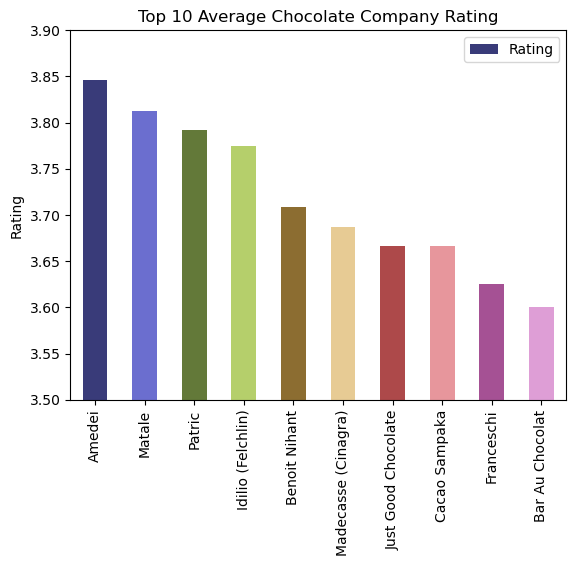

In [1232]:
cmap = plt.colormaps['tab20b']
colors = cmap(np.linspace(0, 1, 10))

topCompaniesAllTime.plot(kind='bar', x='Company',y='Rating',color=colors)
plt.xlabel('')
plt.ylabel('Rating')
plt.title('Top 10 Average Chocolate Company Rating')
plt.ylim(3.5,3.9)
plt.xticks(rotation=90)
plt.show()

Amedei was the winner by scoring an average overall score of 3.85. All top ten chocolate company scores were within a range of 3.6 to 3.9.

# Focused DataFrame on Top 10 Companies

In [1233]:
dfAllTime = df[df['Company'].isin(topCompaniesAllTime['Company'].values)]
dfAllTime

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
75,Amedei,2012,0.70,Italy,3.75,Piura,Peru,Unknown
76,Amedei,2007,0.70,Italy,4.00,Porcelana,Venezuela,Criollo
77,Amedei,2007,0.75,Italy,4.00,Nine,Unknown,Blend
78,Amedei,2007,0.70,Italy,5.00,Chuao,Venezuela,Trinitario
79,Amedei,2007,0.70,Italy,3.00,Ecuador,Ecuador,Trinitario
...,...,...,...,...,...,...,...,...
1273,Patric,2009,0.75,U.S.A.,4.00,Madagascar,Madagascar,Trinitario
1274,Patric,2009,0.67,U.S.A.,3.50,Madagascar,Madagascar,Trinitario
1275,Patric,2009,0.70,U.S.A.,3.50,Rio,Venezuela,Trinitario
1276,Patric,2007,0.70,U.S.A.,4.00,Madagascar,Madagascar,Trinitario


In [1234]:
dfAllTime.shape

(64, 8)

From the original DataFrame find all entries that only pertain to the topmost scoring companies (as we detailed previously). This new DataFrame (64 entries) will be our baseline comparison when analyzing top performing factors in the chocolate making business.

### Company Locations vs Locations with the Highest Rating

In [1173]:
## top company factories are located in these countries
companyLocations = dfAllTime.groupby(['Company','Company Location'])['Rating'].mean().reset_index().sort_values(by='Rating', ascending=False)
companyLocations

,Company,Company Location,Rating
0,Amedei,Italy,3.846154
8,Matale,Australia,3.812500
9,Patric,U.S.A.,3.791667
5,Idilio (Felchlin),Switzerland,3.775000
2,Benoit Nihant,Belgium,3.708333
7,Madecasse (Cinagra),Madagascar,3.687500
3,Cacao Sampaka,Spain,3.666667
6,Just Good Chocolate,U.S.A.,3.666667
4,Franceschi,Venezuela,3.625000
1,Bar Au Chocolat,U.S.A.,3.600000


In [1174]:
## locations with the highest rating
topLocations = df.groupby(['Company Location'])['Rating'].mean().reset_index().sort_values(by='Rating', ascending=False).head(10)
topLocations

,Company Location,Rating
0,Amsterdam,3.500000
26,Netherlands,3.500000
30,Poland,3.500000
41,Vietnam,3.450000
19,Iceland,3.416667
16,Guatemala,3.416667
2,Australia,3.383333
37,Switzerland,3.382353
22,Italy,3.358333
9,Denmark,3.354167


These are the top ten Locations that offer the highest average rating.

In [1175]:
locations_df = df[df['Company Location'].isin(topLocations['Company Location'].values)]
locations_df

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
32,Akesson's (Pralus),2011,0.75,Switzerland,3.75,Bali,Indonesia,Trinitario
33,Akesson's (Pralus),2010,0.75,Switzerland,2.75,Madagascar,Madagascar,Criollo
34,Akesson's (Pralus),2010,0.75,Switzerland,2.75,Monte Alegre,Brazil,Forastero
40,Alexandre,2017,0.70,Netherlands,3.50,Winak,Ecuador,Forastero
41,Alexandre,2017,0.70,Netherlands,3.50,La Dalia,Nicaragua,Criollo
...,...,...,...,...,...,...,...,...
1773,Zokoko,2016,0.78,Australia,3.75,Guadalcanal,Solomon Islands,Unknown
1774,Zokoko,2016,0.65,Australia,3.25,Goddess Blend,Unknown,Unknown
1775,Zokoko,2011,0.68,Australia,3.50,Alto Beni,Bolivia,Unknown
1776,Zokoko,2011,0.66,Australia,3.50,Tokiala,Papua New Guinea,Trinitario


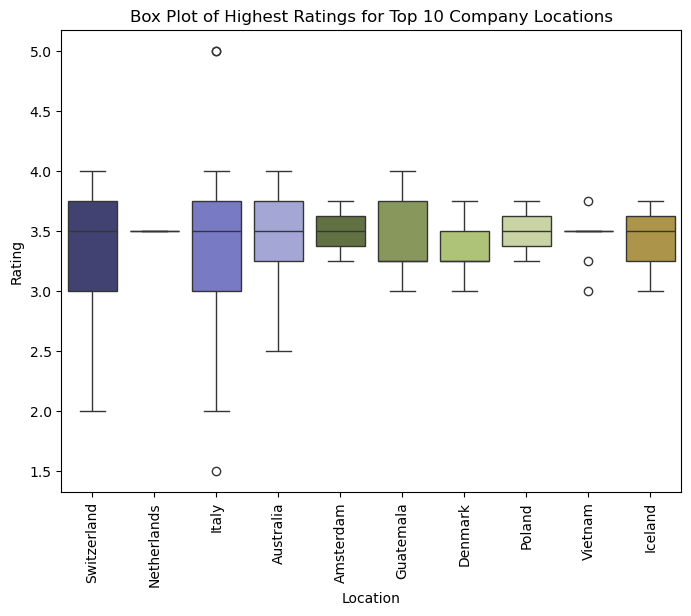

In [1176]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Company Location',y='Rating', data=locations_df, hue='Company Location', palette='tab20b')
plt.ylabel('Rating')
plt.xlabel('Location')
plt.title('Box Plot of Highest Ratings for Top 10 Company Locations')
plt.xticks(rotation=90)
plt.show()

Box plot analyzing the distribution of ratings for each Location from the DataFrame. Some outliers exist in Vietnam and Italy. While Others only contain one entry (Netherlands). In general, ratings are seen from less than 3.0 to 4.0.

In [1390]:
companyLocations_count = companyLocations.groupby(['Company Location'])['Company'].count().reset_index()
companyLocations_count

,Company Location,Company
0,Australia,1
1,Belgium,1
2,Italy,1
3,Madagascar,1
4,Spain,1
5,Switzerland,1
6,U.S.A.,3
7,Venezuela,1


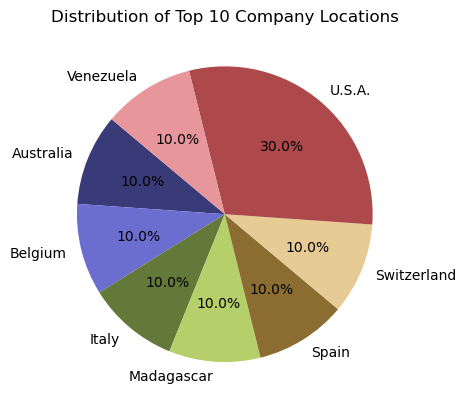

In [1391]:
plt.pie(companyLocations_count['Company'], labels=companyLocations_count['Company Location'].values, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Distribution of Top 10 Company Locations')
plt.show()

Three top ten companies reside in America. The rest of the Companies are distributed across the globe. Three companies come from the top ten highest average rated locations (Australia, Switzerland, Italy).

In [1392]:
topLocations_count = df.groupby(['Company Location'])['Company'].count().reset_index().sort_values(by='Company', ascending=False).head(10)
topLocations_count

,Company Location,Company
39,U.S.A.,653
13,France,143
6,Canada,114
38,U.K.,82
22,Italy,60
2,Australia,45
11,Ecuador,44
4,Belgium,35
37,Switzerland,34
3,Austria,26


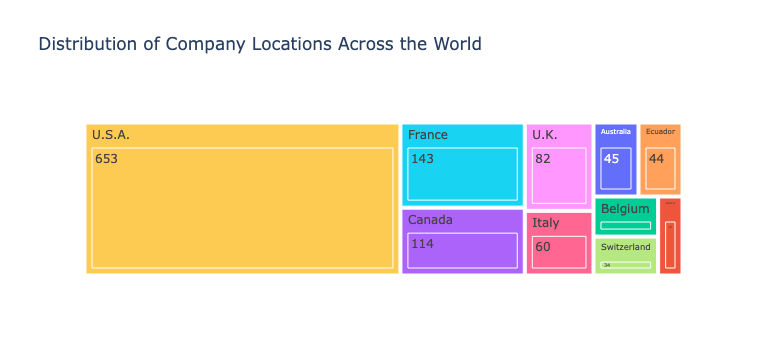

In [1393]:
import plotly.express as px
fig = px.treemap(topLocations_count, path=['Company Location','Company'],
                 values='Company', title='Distribution of Company Locations Across the World', color='Company Location')
fig.show()

Treemap displays the distribution of Chocolate companies across the globe. These are the top 10 most popular locations for companies to reside in. As we can see, USA contains the most amount of companies (653), while Austria contains the tenth most amount of comapnies (26). It makes logical sense for a couple of USA companies to reside in the top ten overall rated companies, seeing as they have so many.

### Cocoa Percentage vs Highest Result

what percentage do companies use?
What’s the relationship between cocoa solids percentage and rating?

In [1394]:
cocoaComp_top = dfAllTime.groupby(['Cocoa Percentage'])['Company'].count().reset_index().sort_values(by=['Cocoa Percentage'], ascending=True)
cocoaComp_top

,Cocoa Percentage,Company
0,0.60,1
1,0.63,2
2,0.66,1
3,0.67,3
4,0.68,1
5,0.70,30
6,0.71,5
7,0.72,11
8,0.73,1
9,0.74,5


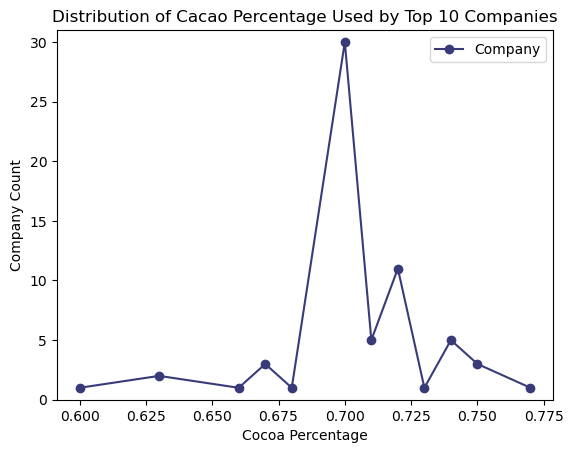

In [1395]:
cocoaComp_top.plot(kind='line',marker='o', color=colors, x='Cocoa Percentage', y='Company')
plt.title('Distribution of Cacao Percentage Used by Top 10 Companies')
plt.ylabel('Company Count')
plt.xlabel('Cocoa Percentage')
plt.ylim(0,31)
plt.show()

Distribution of Cacao Percentage used by the top ten Chocolate companies. The most common percentage used is 70%, folowed by 72%. The least common used are 60%, 66%, 68%, 73%,77%.

In [1396]:
cocoaRating_top = dfAllTime.groupby(['Cocoa Percentage','Rating'])['Company'].count().reset_index().sort_values(by=['Cocoa Percentage'], ascending=True)
cocoaRating_top

,Cocoa Percentage,Rating,Company
0,0.60,3.50,1
1,0.63,3.50,1
2,0.63,4.00,1
3,0.66,4.00,1
4,0.67,3.50,2
5,0.67,4.00,1
6,0.68,4.00,1
7,0.70,3.00,2
8,0.70,3.25,1
9,0.70,3.50,9


In [1397]:
cocoa_pivot = cocoaRating_top.pivot_table(values='Company',
                         index='Cocoa Percentage', columns='Rating', aggfunc='sum').fillna(0)
cocoa_pivot

Rating,3.00,3.25,3.50,3.75,4.00,5.00
Cocoa Percentage,,,,,,
0.60,0.0,0.0,1.0,0.0,0.0,0.0
0.63,0.0,0.0,1.0,0.0,1.0,0.0
0.66,0.0,0.0,0.0,0.0,1.0,0.0
0.67,0.0,0.0,2.0,0.0,1.0,0.0
0.68,0.0,0.0,0.0,0.0,1.0,0.0
0.70,2.0,1.0,9.0,8.0,8.0,2.0
0.71,0.0,1.0,2.0,1.0,1.0,0.0
0.72,0.0,1.0,2.0,5.0,3.0,0.0
0.73,0.0,0.0,0.0,0.0,1.0,0.0


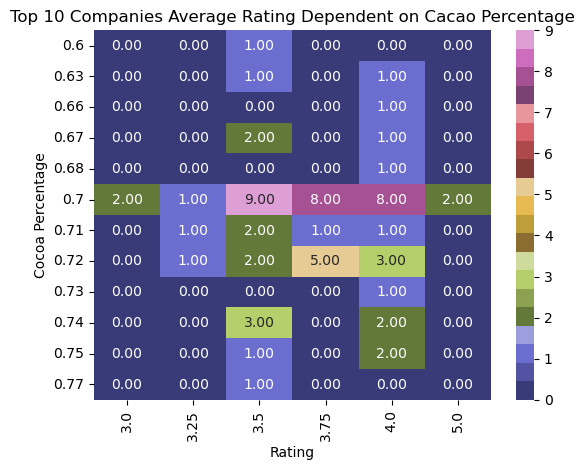

In [1398]:
sns.heatmap(cocoa_pivot, annot=True, fmt='.2f', cmap='tab20b')
plt.xticks(rotation=90)
plt.title('Top 10 Companies Average Rating Dependent on Cacao Percentage')
plt.show()

Visualizing the distribution of ratings depending on Cacao Percentage from the top ten companies. When using 70% cacao, the most common rating is a 3.0-5.0. At 72% cacao, the rating is focused on 3.75, but can also be 3.25-4.0. There appears to be no strict correlation between rating ans cacao percentage, which means that the overall rating is an amalgamation of various factors.

In [1477]:
cocoaComp_gen = df.groupby(['Cocoa Percentage'])['Rating'].count().reset_index().sort_values(by=['Rating'], ascending=False).head(10)
cocoaComp_gen

,Cocoa Percentage,Rating
17,0.70,562
24,0.75,198
19,0.72,155
12,0.65,67
28,0.80,63
23,0.74,43
15,0.68,39
6,0.60,35
21,0.73,31
33,0.85,31


In [1478]:
cocoaPercent_gen_df = df[df['Cocoa Percentage'].isin(cocoaComp_gen['Cocoa Percentage'].values)]
cocoaPercent_gen_df

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
1,A. Morin,2015,0.70,France,2.75,Kpime,Togo,Unknown
2,A. Morin,2015,0.70,France,3.00,Atsane,Togo,Unknown
3,A. Morin,2015,0.70,France,3.50,Akata,Togo,Unknown
4,A. Morin,2015,0.70,France,3.50,Quilla,Peru,Unknown
5,A. Morin,2014,0.70,France,2.75,Carenero,Venezuela,Criollo
...,...,...,...,...,...,...,...,...
1788,Zotter,2012,0.68,Austria,3.25,Kongo,Congo,Forastero
1790,Zotter,2011,0.70,Austria,3.75,Peru,Peru,Unknown
1791,Zotter,2011,0.65,Austria,3.00,Congo,Congo,Forastero
1792,Zotter,2011,0.65,Austria,3.50,Kerala State,India,Forastero


In [1479]:
cocoaPerc_gen_df_counts = cocoaPercent_gen_df.groupby(['Cocoa Percentage','Rating'])['Company'].count().reset_index().sort_values(by=['Cocoa Percentage'], ascending=True)
cocoaPerc_gen_df_counts

,Cocoa Percentage,Rating,Company
0,0.60,2.00,1
1,0.60,2.50,5
2,0.60,2.75,5
3,0.60,3.00,11
4,0.60,3.25,8
...,...,...,...
79,0.85,2.00,1
80,0.85,2.50,3
81,0.85,2.75,7
82,0.85,3.00,7


In [1480]:
cocoa_gen_pivot = cocoaPerc_gen_df_counts.pivot_table(values='Company',
                         index='Cocoa Percentage', columns='Rating', aggfunc='sum').fillna(0)
cocoa_gen_pivot

Rating,1.00,1.50,1.75,2.00,2.25,2.50,2.75,3.00,3.25,3.50,3.75,4.00,5.00
Cocoa Percentage,,,,,,,,,,,,,
0.60,0.0,0.0,0.0,1.0,0.0,5.0,5.0,11.0,8.0,3.0,1.0,1.0,0.0
0.65,0.0,1.0,0.0,1.0,1.0,3.0,7.0,12.0,16.0,21.0,3.0,2.0,0.0
0.68,0.0,0.0,0.0,1.0,0.0,0.0,6.0,6.0,6.0,11.0,7.0,2.0,0.0
0.70,0.0,0.0,0.0,2.0,2.0,29.0,60.0,93.0,97.0,144.0,92.0,41.0,2.0
0.72,0.0,0.0,1.0,1.0,3.0,4.0,17.0,39.0,31.0,27.0,22.0,10.0,0.0
0.73,1.0,0.0,0.0,1.0,0.0,1.0,3.0,1.0,8.0,11.0,4.0,1.0,0.0
0.74,0.0,0.0,0.0,0.0,0.0,3.0,7.0,7.0,6.0,10.0,6.0,4.0,0.0
0.75,0.0,0.0,0.0,5.0,1.0,16.0,28.0,43.0,33.0,35.0,21.0,16.0,0.0
0.80,0.0,0.0,0.0,1.0,0.0,4.0,17.0,16.0,12.0,8.0,4.0,1.0,0.0


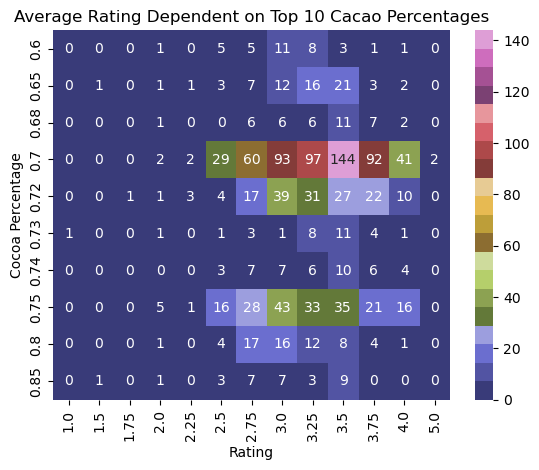

In [1481]:
sns.heatmap(cocoa_gen_pivot, annot=True, fmt='.0f', cmap='tab20b')
plt.xticks(rotation=90)
plt.title('Average Rating Dependent on Top 10 Cacao Percentages')
plt.show()

General distribution of ratings when looking at the top 10 most used cacao percentages. 70% cacao will commonly return a rating of 3.5. But has a general distribution between 2.5-4.0. At 72% cacao and 75% cacao, we see the numbers go up again with average ratings landing between 3.0 and 3.75.

### Company Location vs Cacao Percentage
how do locations utilize different cacao percentages.

In [1408]:
locPercent_top = dfAllTime.groupby(['Company Location','Cocoa Percentage'])['Rating'].mean().reset_index().sort_values(by=['Rating'], ascending=False)
locPercent_top

,Company Location,Cocoa Percentage,Rating
0,Australia,0.68,4.000000
23,U.S.A.,0.75,4.000000
3,Australia,0.74,4.000000
5,Belgium,0.73,4.000000
20,Switzerland,0.74,4.000000
8,Italy,0.66,4.000000
10,Italy,0.75,4.000000
11,Madagascar,0.63,4.000000
18,Switzerland,0.70,4.000000
4,Belgium,0.72,3.875000


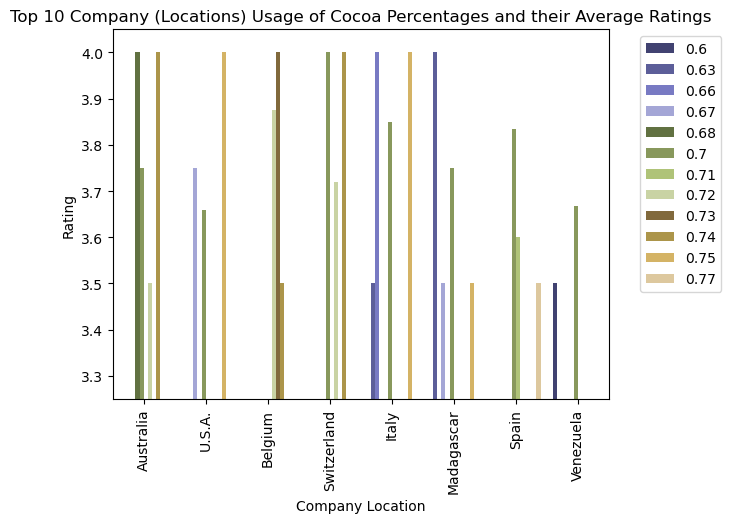

In [1409]:
sns.barplot(data=locPercent_top, x="Company Location", y="Rating", hue="Cocoa Percentage", palette='tab20b')
plt.title('Top 10 Company (Locations) Usage of Cocoa Percentages and their Average Ratings')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(3.25,4.05)
plt.show()

Top ten companies are based in seven locations. Switzerland and Italy have the most consistent high ratings with 70%,72%,74% and 66%,70%,75% respectively. Venezuela, despite also using a percentage of 70%, only managed to reach a score of less than 3.7.

### Average Broad Bean Origin Ratings

In [1416]:
originPer_top = dfAllTime.groupby(['Broad Bean Origin', 'Rating'])['Company'].count().reset_index().sort_values(by=['Broad Bean Origin'], ascending=False)
originPer_top

,Broad Bean Origin,Rating,Company
31,Venezuela,5.00,1
30,Venezuela,4.00,5
29,Venezuela,3.75,7
28,Venezuela,3.50,8
27,Venezuela,3.25,1
26,Vanuatu,3.50,1
25,Unknown,5.00,1
24,Unknown,4.00,2
23,Unknown,3.75,1
22,Unknown,3.50,1


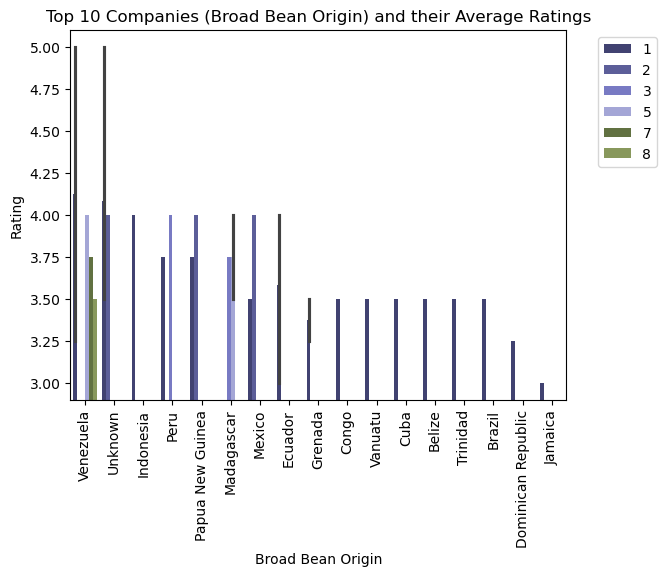

In [1411]:
sns.barplot(data=originPer_top, x="Broad Bean Origin", y="Rating", hue="Company", palette='tab20b')
plt.title('Top 10 Companies (Broad Bean Origin) and their Average Ratings')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(2.9,5.1)
plt.show()

Most beans from the top ten companies originate from Venezuela, Madagascar, or Peru. Any location that has more than one company sourcing from there tend to get an average score of 4.0. Which in actuality is a great score. Locations that are only sorced by one company have an average score of 3.5 or lower. Which is where we begin to see a decrease in favorability from critics. 

In [1426]:
broadOrigin_gen = df.groupby(['Broad Bean Origin', 'Rating'])['Company'].count().reset_index().sort_values(by=['Rating', 'Broad Bean Origin'], ascending=False).head(10)
broadOrigin_gen

,Broad Bean Origin,Rating,Company
252,Venezuela,5.0,1
236,Unknown,5.0,1
258,Vietnam,4.0,1
251,Venezuela,4.0,21
235,Unknown,4.0,2
205,St. Lucia,4.0,1
199,South America,4.0,1
194,Sao Tome,4.0,2
178,Peru,4.0,12
169,Papua New Guinea,4.0,5


In [1427]:
broadOrigin_gen_df = df[df['Broad Bean Origin'].isin(broadOrigin_gen['Broad Bean Origin'].values)]
broadOrigin_gen_df[['Broad Bean Origin', 'Rating']]

,Broad Bean Origin,Rating
0,Sao Tome,3.75
4,Peru,3.50
5,Venezuela,2.75
7,Venezuela,3.50
8,Venezuela,3.75
...,...,...
1781,Peru,3.00
1782,Peru,3.50
1785,Papua New Guinea,3.00
1789,Unknown,3.50


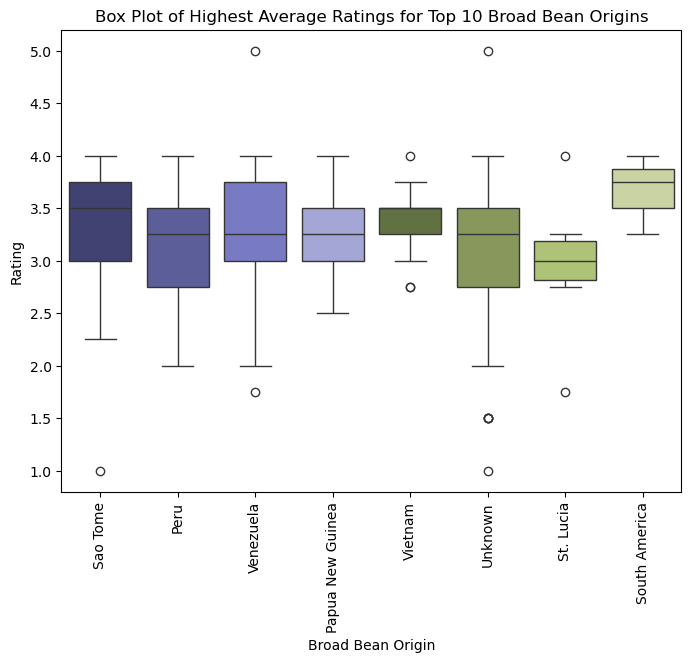

In [1428]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Broad Bean Origin',y='Rating', data=broadOrigin_gen_df, hue='Broad Bean Origin', palette='tab20b')
plt.ylabel('Rating')
plt.xlabel('Broad Bean Origin')
plt.title('Box Plot of Highest Average Ratings for Top 10 Broad Bean Origins')
plt.xticks(rotation=90)
plt.show()

In general, the most popular and highest rated beans are sourced from Venezuela, Peru, and Papua New Guinea. This correlates positively with the results we just saw from the top ten companies with the highest ratings. Those sources from Venezuela, Peru, and PNG are seen to have scored higher than those sourced elsewhere.

### Bean Type vs Rating

In [1304]:
typeRating_top= dfAllTime.groupby(['Bean Type'])['Rating'].mean().reset_index().sort_values(by='Rating', ascending=False)
typeRating_top

,Bean Type,Rating
0,Blend,4.050000
2,Forastero,4.000000
1,Criollo,3.729167
3,Trinitario,3.708333
4,Unknown,3.687500


In [1315]:
typeRating_top_count= dfAllTime.groupby(['Bean Type', 'Rating'])['Company'].count().reset_index().sort_values(by='Company', ascending=False)
typeRating_top_count

,Bean Type,Rating,Company
11,Trinitario,3.50,11
13,Trinitario,4.00,9
16,Unknown,3.50,6
12,Trinitario,3.75,6
17,Unknown,3.75,5
7,Criollo,4.00,5
18,Unknown,4.00,4
5,Criollo,3.50,4
9,Trinitario,3.00,2
6,Criollo,3.75,2


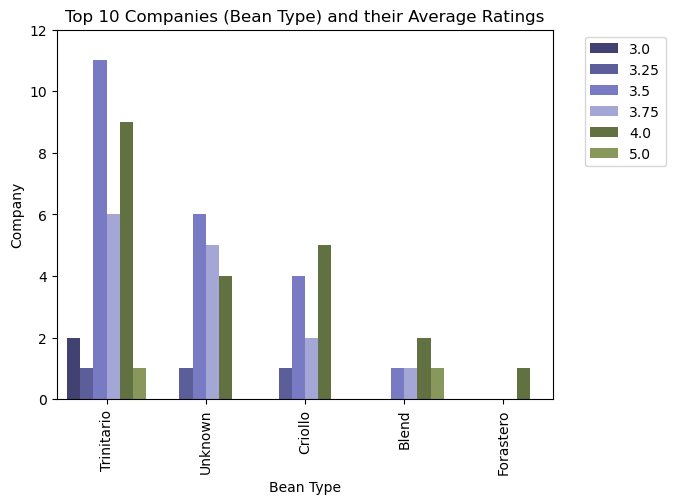

In [1316]:
sns.barplot(data=typeRating_top_count, x="Bean Type", y="Company", hue='Rating', palette='tab20b')
plt.title('Top 10 Companies (Bean Type) and their Average Ratings')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0,12)
plt.show()

The highest rated bean type is Blend followed by Forastero and Criollo. Trinitario is the most commonly used Bean Type and Forastero only has one entry in the data.

In [1419]:
typeRating_gen= df.groupby(['Bean Type'])['Rating'].max().reset_index().sort_values(by='Rating', ascending=False).head(10)
typeRating_gen

,Bean Type,Rating
2,Blend,5.00
9,Trinitario,5.00
0,Amazon,4.00
4,Criollo,4.00
6,Forastero,4.00
10,Unknown,4.00
1,Beniano,3.75
5,EET,3.75
7,Matina,3.75
8,Nacional,3.75


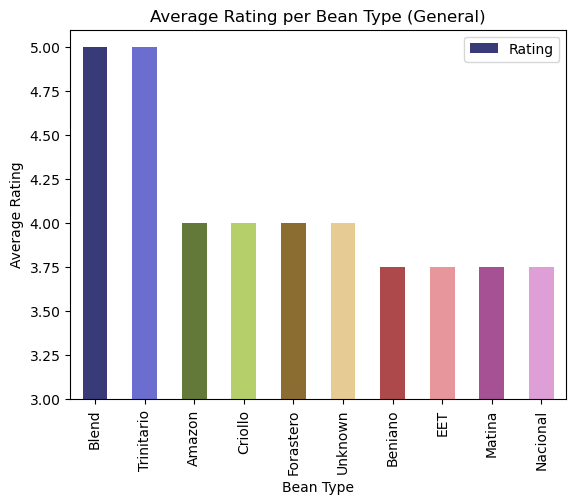

In [1422]:
typeRating_gen.plot(kind='bar', x='Bean Type',y='Rating',color=colors)
plt.xlabel('Bean Type')
plt.ylabel('Average Rating')
plt.title('Average Rating per Bean Type (General)')
plt.ylim(3,5.1)
plt.show()

The Blend, Trinitario, and Amazon are the best bean types in general, since they generated the highest ratings. The top ten companies consistenly utilize both the Blend type and the Trinitario type of bean.

### Top Companies and their Bean Origins

In [1438]:
companyOrigin_top = dfAllTime.groupby(['Company','Bean Origin'])['Rating'].mean().reset_index().sort_values(by=['Company','Rating'], ascending=False)
companyOrigin_top

,Company,Bean Origin,Rating
50,Patric,Piura,4.000000
49,Patric,Madagascar,3.833333
52,Patric,Signature Blend,3.750000
51,Patric,Rio,3.500000
46,Matale,Kulili,4.000000
48,Matale,Somia,4.000000
45,Matale,Blend,3.750000
47,Matale,Malekula,3.500000
44,Madecasse (Cinagra),Madagascar,3.687500
43,Just Good Chocolate,Peru,4.000000


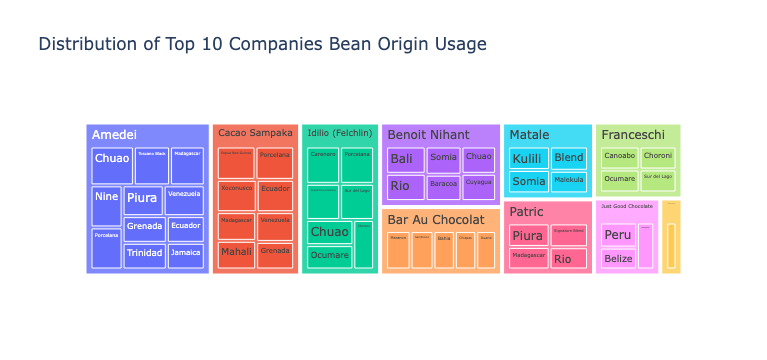

In [1439]:
fig = px.treemap(companyOrigin_top, path=['Company','Bean Origin'],
                 values='Rating', title='Distribution of Top 10 Companies Bean Origin Usage')
fig.show()

Amedei utilizes a large varitey of Beans from specific origins. The beans from Chuao, Toscano Black, and Madagascar yielded the best ratings. Similarly, Cacao Sampaka recieved high scores when using beans from Papua New Guinea, Prcelana, and Xoconusco.

In [1261]:
companyBroad_top = dfAllTime.groupby(['Company Location','Broad Bean Origin'])['Rating'].mean().reset_index().sort_values(by=['Company Location','Rating'], ascending=False)
companyBroad_top

,Company Location,Broad Bean Origin,Rating
33,Venezuela,Venezuela,3.6250
30,U.S.A.,Peru,4.0000
28,U.S.A.,Madagascar,3.7500
31,U.S.A.,Unknown,3.7500
25,U.S.A.,Belize,3.5000
26,U.S.A.,Brazil,3.5000
29,U.S.A.,Mexico,3.5000
32,U.S.A.,Venezuela,3.5000
27,U.S.A.,Dominican Republic,3.2500
24,Switzerland,Venezuela,3.7750


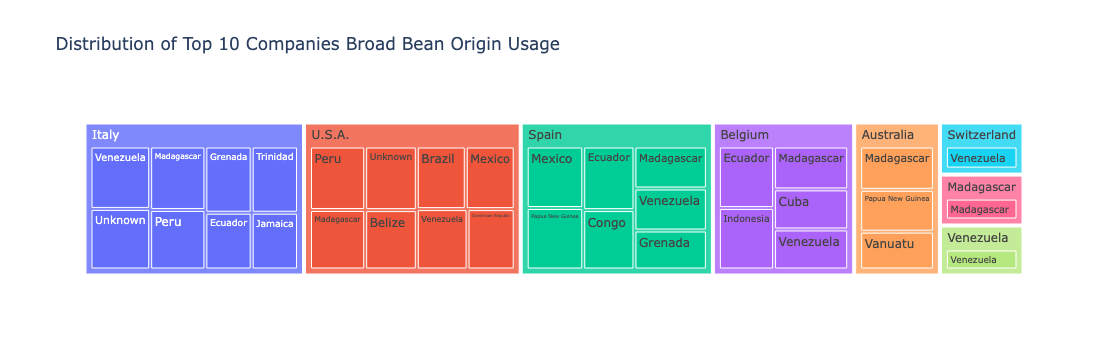

In [1263]:
fig = px.treemap(companyBroad_top, path=['Company Location','Broad Bean Origin'],
                 values='Rating', title='Distribution of Top 10 Companies Broad Bean Origin Usage')
fig.show()

Italy, USA, and Spain are Locations that generated the highest ratings depenedent on the beans they used in their chocolate bars. These beans on average came from Venezuela, Madagascar, Peru, mexico, Grenada, or Ecuador.

### Best Beans (Bean Origin)

In [1483]:
beanRating_top = dfAllTime.groupby(['Bean Origin'])['Rating'].mean().reset_index().sort_values(by='Rating', ascending=False).head(10)
beanRating_top

,Bean Origin,Rating
32,Toscano Black,4.166667
9,Chuao,4.083333
35,Xoconusco,4.000000
21,Nine,4.000000
20,Maranon,4.000000
1,Bali,4.000000
16,Kulili,4.000000
26,Porcelana,4.000000
24,Peru,4.000000
23,Papua New Guinea,4.000000


In [1487]:
beanRating_gen = df.groupby(['Bean Origin'])['Rating'].max().reset_index().sort_values(by='Rating', ascending=False).head(10)
beanRating_gen

,Bean Origin,Rating
102,Chuao,5.0
420,Toscano Black,5.0
345,Piura,4.0
44,Bachelor's Hall E.,4.0
299,Monte Alegre,4.0
301,Morobe,4.0
312,Nine,4.0
322,Ocumare,4.0
105,Chuno,4.0
190,Haiti,4.0


In [1432]:
beanRating_gen_df = df[df['Bean Origin'].isin(beanRating_gen['Bean Origin'].values)]
beanRating_gen_df[['Bean Origin', 'Rating']]

,Bean Origin,Rating
17,Chuao,4.00
18,Piura,3.25
34,Monte Alegre,2.75
38,Chuao,2.50
39,Piura,2.50
...,...,...
1553,Ocumare,3.75
1682,Piura,4.00
1692,Chuao,3.75
1730,Ocumare,2.50


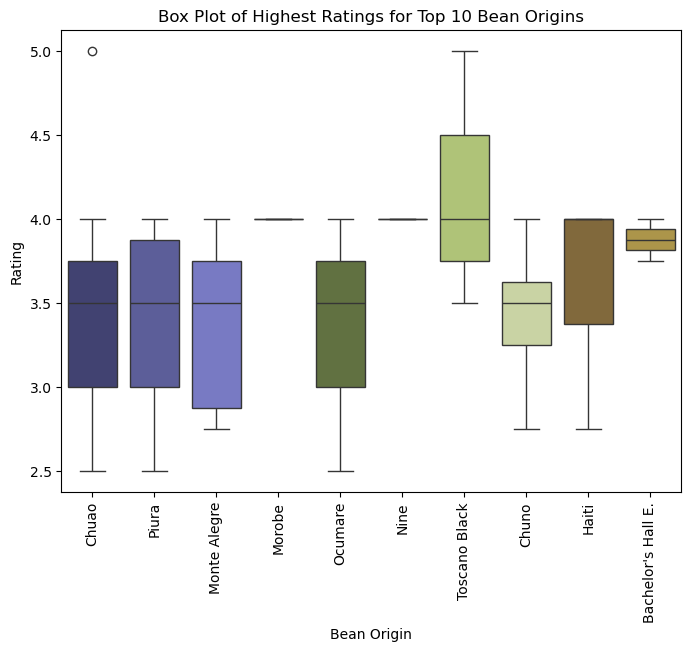

In [1433]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Bean Origin',y='Rating', data=beanRating_gen_df, hue='Bean Origin', palette='tab20b')
plt.ylabel('Rating')
plt.xlabel('Bean Origin')
plt.title('Box Plot of Highest Ratings for Top 10 Bean Origins')
plt.xticks(rotation=90)
plt.show()

The most popoular Beans from specific geolocations are from Chuao, Toscano Black, Piura. With Chuao beans giving a outlier score of 5.0.

### Top Performing Years for Each Company

In [1440]:
## avg performance for companies throughout the years
bestYear_top = dfAllTime.groupby(['Review Date', 'Company'])['Rating'].mean().reset_index().sort_values(by='Rating', ascending=True)
bestYear_top

,Review Date,Company,Rating
21,2016,Cacao Sampaka,3.500000
20,2015,Bar Au Chocolat,3.500000
11,2012,Bar Au Chocolat,3.500000
6,2010,Cacao Sampaka,3.583333
18,2014,Franceschi,3.625000
13,2013,Benoit Nihant,3.625000
12,2012,Franceschi,3.625000
19,2014,Just Good Chocolate,3.666667
5,2009,Patric,3.666667
3,2008,Madecasse (Cinagra),3.687500


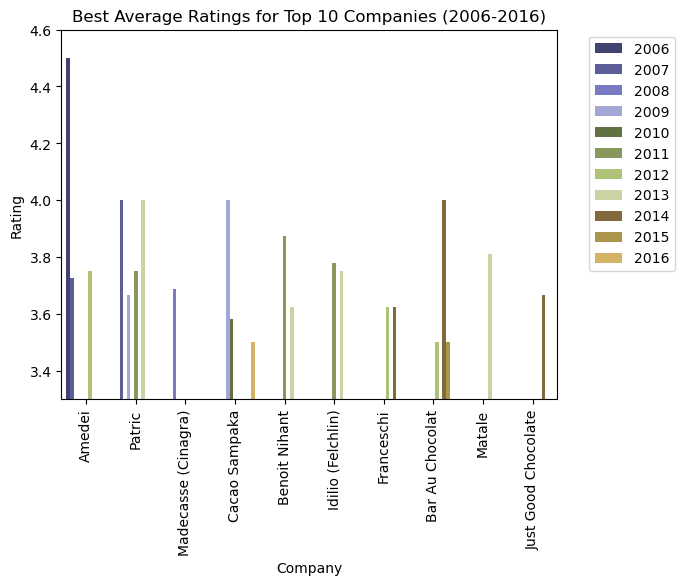

In [1346]:
sns.barplot(data=bestYear_top, x="Company", y="Rating", hue="Review Date", palette='tab20b')
plt.title('Best Average Ratings for Top 10 Companies (2006-2016)')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(3.3,4.6)
plt.show()

Above you can observe the best performing year for all top ten companies. Amedei's best year was 2006. WHile Patric had two good years on 2007 and 2013.

## The Objective Best

### Top 10 Comapnies Usage of Best Bean Type

In [1441]:
genType = typeRating_gen['Bean Type'].head(5).values
genTypes = genType[genType != 'Unknown']
genTypes

array(['Blend', 'Trinitario', 'Amazon', 'Criollo', 'Forastero'],
      dtype=object)

In [1442]:
df_bestBean = dfAllTime[(dfAllTime['Bean Type'].isin(genTypes))]
df_bestBean

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
76,Amedei,2007,0.70,Italy,4.00,Porcelana,Venezuela,Criollo
77,Amedei,2007,0.75,Italy,4.00,Nine,Unknown,Blend
78,Amedei,2007,0.70,Italy,5.00,Chuao,Venezuela,Trinitario
79,Amedei,2007,0.70,Italy,3.00,Ecuador,Ecuador,Trinitario
80,Amedei,2007,0.70,Italy,3.00,Jamaica,Jamaica,Trinitario
81,Amedei,2007,0.70,Italy,3.50,Grenada,Grenada,Trinitario
82,Amedei,2007,0.70,Italy,3.75,Venezuela,Venezuela,Trinitario
83,Amedei,2007,0.70,Italy,4.00,Madagascar,Madagascar,Trinitario
84,Amedei,2007,0.70,Italy,3.50,Trinidad,Trinidad,Trinitario
85,Amedei,2007,0.63,Italy,3.50,Toscano Black,Unknown,Blend


Nine out of the top ten companies utilizes the 'best bean' types. 

Only Franceschi does not use any of these bean types.

### Top 10 Companies Usage of Best Company Location

In [1443]:
genLocations = topLocations['Company Location'].values
genLocations

array(['Amsterdam', 'Netherlands', 'Poland', 'Vietnam', 'Iceland',
       'Guatemala', 'Australia', 'Switzerland', 'Italy', 'Denmark'],
      dtype=object)

In [1444]:
df_bestLoc = dfAllTime[(dfAllTime['Company Location'].isin(genLocations))]
df_bestLoc

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
75,Amedei,2012,0.70,Italy,3.75,Piura,Peru,Unknown
76,Amedei,2007,0.70,Italy,4.00,Porcelana,Venezuela,Criollo
77,Amedei,2007,0.75,Italy,4.00,Nine,Unknown,Blend
78,Amedei,2007,0.70,Italy,5.00,Chuao,Venezuela,Trinitario
79,Amedei,2007,0.70,Italy,3.00,Ecuador,Ecuador,Trinitario
80,Amedei,2007,0.70,Italy,3.00,Jamaica,Jamaica,Trinitario
81,Amedei,2007,0.70,Italy,3.50,Grenada,Grenada,Trinitario
82,Amedei,2007,0.70,Italy,3.75,Venezuela,Venezuela,Trinitario
83,Amedei,2007,0.70,Italy,4.00,Madagascar,Madagascar,Trinitario
84,Amedei,2007,0.70,Italy,3.50,Trinidad,Trinidad,Trinitario


Three companies are located in top Company Locations.

Amedei - Italy

Idilio (Felchin) - Switzerland

Matale - Australia

### Top 10 Companies Usage of Best Cocoa Percentage

In [1352]:
genPercent = cocoaRating_gen['Cocoa Percentage'].head(10).values
genPercent

array([0.7 , 0.88, 0.8 , 0.78, 0.75, 0.74, 0.73, 0.72, 0.71, 0.69])

In [1353]:
df_bestPer = dfAllTime[(dfAllTime['Cocoa Percentage'].isin(genPercent))]
df_bestPer

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
75,Amedei,2012,0.70,Italy,3.75,Piura,Peru,Unknown
76,Amedei,2007,0.70,Italy,4.00,Porcelana,Venezuela,Criollo
77,Amedei,2007,0.75,Italy,4.00,Nine,Unknown,Blend
78,Amedei,2007,0.70,Italy,5.00,Chuao,Venezuela,Trinitario
79,Amedei,2007,0.70,Italy,3.00,Ecuador,Ecuador,Trinitario
80,Amedei,2007,0.70,Italy,3.00,Jamaica,Jamaica,Trinitario
81,Amedei,2007,0.70,Italy,3.50,Grenada,Grenada,Trinitario
82,Amedei,2007,0.70,Italy,3.75,Venezuela,Venezuela,Trinitario
83,Amedei,2007,0.70,Italy,4.00,Madagascar,Madagascar,Trinitario
84,Amedei,2007,0.70,Italy,3.50,Trinidad,Trinidad,Trinitario


All top ten companies use the best possible cocoa percentages.

### Top 10 Companies Usage of Best Broad Bean Origin

In [1449]:
genBroad = broadOrigin_gen['Broad Bean Origin'].head(10).values
genBroad

array(['Venezuela', 'Unknown', 'Vietnam', 'Venezuela', 'Unknown',
       'St. Lucia', 'South America', 'Sao Tome', 'Peru',
       'Papua New Guinea'], dtype=object)

In [1450]:
df_bestBroad = dfAllTime[(dfAllTime['Broad Bean Origin'].isin(genBroad))]
df_bestBroad

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
75,Amedei,2012,0.70,Italy,3.75,Piura,Peru,Unknown
76,Amedei,2007,0.70,Italy,4.00,Porcelana,Venezuela,Criollo
77,Amedei,2007,0.75,Italy,4.00,Nine,Unknown,Blend
78,Amedei,2007,0.70,Italy,5.00,Chuao,Venezuela,Trinitario
82,Amedei,2007,0.70,Italy,3.75,Venezuela,Venezuela,Trinitario
85,Amedei,2007,0.63,Italy,3.50,Toscano Black,Unknown,Blend
86,Amedei,2006,0.70,Italy,5.00,Toscano Black,Unknown,Blend
87,Amedei,2006,0.66,Italy,4.00,Toscano Black,Unknown,Blend
152,Bar Au Chocolat,2014,0.70,U.S.A.,4.00,Maranon,Peru,Forastero
177,Benoit Nihant,2013,0.74,Belgium,3.50,Chuao,Venezuela,Criollo


Nine out of ten top ten companies use the best broad bean origin beans. (minus Madecasse (Cinagra)).

### Top 10 Companies Usage of Best Bean Origin

In [1451]:
genOrigin = beanRating_gen['Bean Origin'].head(10).values
genOrigin

array(['Chuao', 'Toscano Black', 'Piura', "Bachelor's Hall E.",
       'Monte Alegre', 'Morobe', 'Nine', 'Ocumare', 'Chuno', 'Haiti'],
      dtype=object)

In [1452]:
df_bestOrigin = dfAllTime[(dfAllTime['Bean Origin'].isin(genOrigin))]
df_bestOrigin

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
75,Amedei,2012,0.70,Italy,3.75,Piura,Peru,Unknown
77,Amedei,2007,0.75,Italy,4.00,Nine,Unknown,Blend
78,Amedei,2007,0.70,Italy,5.00,Chuao,Venezuela,Trinitario
85,Amedei,2007,0.63,Italy,3.50,Toscano Black,Unknown,Blend
86,Amedei,2006,0.70,Italy,5.00,Toscano Black,Unknown,Blend
87,Amedei,2006,0.66,Italy,4.00,Toscano Black,Unknown,Blend
177,Benoit Nihant,2013,0.74,Belgium,3.50,Chuao,Venezuela,Criollo
661,Franceschi,2014,0.70,Venezuela,3.75,Ocumare,Venezuela,Unknown
856,Idilio (Felchlin),2013,0.72,Switzerland,3.75,Chuao,Venezuela,Trinitario
860,Idilio (Felchlin),2011,0.72,Switzerland,3.75,Ocumare,Venezuela,Criollo


Five out of Ten companies use the best Specific Bean Origin Beans. (Amedei, Benoit Nihant, Franceschi, Idilio (Felchlin), Patric)

###

Objectively, Amedei is the optimal chocolate company since it fufills all of the required factors to 'be great'. They use the correct Bean Type, Location, Percentage, Broad Bean Origin, and Bean Origin.

### Top 10 Companies That Utilize One or More of the Best Rated Factors

In [1358]:
dfAllTime.shape

(64, 8)

In [1359]:
df_best = dfAllTime[(dfAllTime['Company Location'].isin(genLocations)) | 
    (dfAllTime['Cocoa Percentage'].isin(genPercent)) |
    (dfAllTime['Bean Type'].isin(genTypes)) |
    (dfAllTime['Broad Bean Origin'].isin(genBroad)) |
    (dfAllTime['Bean Origin'].isin(genOrigin))]
df_best

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
75,Amedei,2012,0.70,Italy,3.75,Piura,Peru,Unknown
76,Amedei,2007,0.70,Italy,4.00,Porcelana,Venezuela,Criollo
77,Amedei,2007,0.75,Italy,4.00,Nine,Unknown,Blend
78,Amedei,2007,0.70,Italy,5.00,Chuao,Venezuela,Trinitario
79,Amedei,2007,0.70,Italy,3.00,Ecuador,Ecuador,Trinitario
...,...,...,...,...,...,...,...,...
1273,Patric,2009,0.75,U.S.A.,4.00,Madagascar,Madagascar,Trinitario
1274,Patric,2009,0.67,U.S.A.,3.50,Madagascar,Madagascar,Trinitario
1275,Patric,2009,0.70,U.S.A.,3.50,Rio,Venezuela,Trinitario
1276,Patric,2007,0.70,U.S.A.,4.00,Madagascar,Madagascar,Trinitario


In [1360]:
df_best.shape

(64, 8)

### Top 10 Companies That Utilize One or More of the Best Rated Factors (minus 'Bean Type')

Analysis concludes that Cocoa Percentage remains around the same when comparing best rated chocolate companies and the worst rated chocolate companies. By limiting factors to those that are more unique, we are able to see the stark difference between best companies and the worst companies.

In [1465]:
df_bestNoPer = dfAllTime[(dfAllTime['Company Location'].isin(genLocations)) &
    (dfAllTime['Bean Type'].isin(genTypes)) &
    (dfAllTime['Cocoa Percentage'].isin(genPercent)) &
    (dfAllTime['Broad Bean Origin'].isin(genBroad)) &
    (dfAllTime['Bean Origin'].isin(genOrigin))]
df_bestNoPer

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
77,Amedei,2007,0.75,Italy,4.00,Nine,Unknown,Blend
78,Amedei,2007,0.70,Italy,5.00,Chuao,Venezuela,Trinitario
86,Amedei,2006,0.70,Italy,5.00,Toscano Black,Unknown,Blend
856,Idilio (Felchlin),2013,0.72,Switzerland,3.75,Chuao,Venezuela,Trinitario
860,Idilio (Felchlin),2011,0.72,Switzerland,3.75,Ocumare,Venezuela,Criollo
862,Idilio (Felchlin),2011,0.72,Switzerland,3.50,Ocumare,Venezuela,Criollo


In [1466]:
df_bestNoPer.shape

(6, 8)

In [1453]:
topCompaniesAllTime

,Company,Rating
10,Amedei,3.846154
131,Matale,3.812500
158,Patric,3.791667
102,Idilio (Felchlin),3.775000
22,Benoit Nihant,3.708333
119,Madecasse (Cinagra),3.687500
104,Just Good Chocolate,3.666667
38,Cacao Sampaka,3.666667
82,Franceschi,3.625000
16,Bar Au Chocolat,3.600000


This inital rating is in parallel with our findings. Amedei, matale, Patric, and Idilio are the top four chocolate companies because of the relating components they utilize in their chocolate bars.

## Bottom 10 Companies (Worst Average Ratings)

In [1454]:
bottomCompanies = df.groupby(['Company'])['Rating'].mean().reset_index().sort_values(by='Rating', ascending=False).tail(10)
bottomCompanies

,Company,Rating
202,Vivra,2.666667
189,TCHO,2.656250
152,Olivia,2.625000
48,Chocolarder,2.583333
180,Snake & Butterfly,2.583333
186,StRita Supreme,2.583333
76,Ethel's Artisan (Mars),2.550000
145,Neuhaus (Callebaut),2.500000
200,Vintage Plantations (Tulicorp),2.500000
34,Cacao Atlanta,2.500000


In [1455]:
bottomCompanies_names = bottomCompanies['Company'].values
bottomCompanies['Company'].values

array(['Vivra', 'TCHO', 'Olivia', 'Chocolarder', 'Snake & Butterfly',
       'StRita Supreme', "Ethel's Artisan (Mars)", 'Neuhaus (Callebaut)',
       'Vintage Plantations (Tulicorp)', 'Cacao Atlanta'], dtype=object)

Chocolate companies with the worst overall average ratings.

### New DataFrame with only the 'Worst' Companies

In [1456]:
bottomDF = df[df['Company'].isin(bottomCompanies_names)]
bottomDF

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
280,Cacao Atlanta,2014,0.75,U.S.A.,2.50,Tumbes,Peru,Criollo
281,Cacao Atlanta,2010,0.75,U.S.A.,2.50,Dominican Republic,Dominican Republic,Unknown
282,Cacao Atlanta,2010,0.75,U.S.A.,2.75,Dominican Republic,Dominican Republic,Unknown
283,Cacao Atlanta,2010,0.75,U.S.A.,2.25,Patanemo,Venezuela,Unknown
387,Chocolarder,2015,0.65,U.K.,2.50,Peru,Peru,Criollo
388,Chocolarder,2015,0.65,U.K.,2.75,Peru,Peru,Criollo
389,Chocolarder,2015,0.80,U.K.,2.50,Dominican Republic,Dominican Republic,Unknown
631,Ethel's Artisan (Mars),2011,0.55,U.S.A.,2.50,Peru,Peru,Unknown
632,Ethel's Artisan (Mars),2011,0.55,U.S.A.,2.50,Trinidad,Trinidad,Trinitario
633,Ethel's Artisan (Mars),2011,0.70,U.S.A.,2.50,Porcelana,Venezuela,Criollo


In [1457]:
bottomDF.shape

(43, 8)

### Bottom 10 Companies That Utilize One or More of the Best Rated Factors (minus 'Bean Type')

In [1467]:
df_worst = bottomDF[(bottomDF['Company Location'].isin(genLocations)) & 
    (bottomDF['Bean Type'].isin(genTypes)) &
    (bottomDF['Cocoa Percentage'].isin(genPercent)) &
    (bottomDF['Broad Bean Origin'].isin(genBroad)) &
    (bottomDF['Bean Origin'].isin(genOrigin))]
df_worst

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type


As seen, no bottom ten company utilizes all important factors when creating chocolate bars, which could be reason for their low ratings.

In [1459]:
df_worst_loc = bottomDF[(bottomDF['Company Location'].isin(genLocations))]
df_worst_loc

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type


In [1468]:
df_worst_type = bottomDF[(bottomDF['Bean Type'].isin(genTypes))]
df_worst_type

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
280,Cacao Atlanta,2014,0.75,U.S.A.,2.50,Tumbes,Peru,Criollo
387,Chocolarder,2015,0.65,U.K.,2.50,Peru,Peru,Criollo
388,Chocolarder,2015,0.65,U.K.,2.75,Peru,Peru,Criollo
632,Ethel's Artisan (Mars),2011,0.55,U.S.A.,2.50,Trinidad,Trinidad,Trinitario
633,Ethel's Artisan (Mars),2011,0.70,U.S.A.,2.50,Porcelana,Venezuela,Criollo
1173,Neuhaus (Callebaut),2010,0.70,Belgium,2.50,Papua New Guinea,Papua New Guinea,Criollo
1174,Neuhaus (Callebaut),2008,0.67,Belgium,3.75,Manickchand Estate,Trinidad,Trinitario
1176,Neuhaus (Callebaut),2006,0.73,Belgium,2.00,West Africa,West Africa,Forastero
1177,Neuhaus (Callebaut),2006,0.75,Belgium,2.75,Sao Tome,Sao Tome,Forastero
1178,Neuhaus (Callebaut),2006,0.71,Belgium,3.00,Ocumare,Venezuela,Criollo


In [1461]:
df_worst_broad = bottomDF[(bottomDF['Broad Bean Origin'].isin(genBroad))]
df_worst_broad

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
280,Cacao Atlanta,2014,0.75,U.S.A.,2.50,Tumbes,Peru,Criollo
283,Cacao Atlanta,2010,0.75,U.S.A.,2.25,Patanemo,Venezuela,Unknown
387,Chocolarder,2015,0.65,U.K.,2.50,Peru,Peru,Criollo
388,Chocolarder,2015,0.65,U.K.,2.75,Peru,Peru,Criollo
631,Ethel's Artisan (Mars),2011,0.55,U.S.A.,2.50,Peru,Peru,Unknown
633,Ethel's Artisan (Mars),2011,0.70,U.S.A.,2.50,Porcelana,Venezuela,Criollo
634,Ethel's Artisan (Mars),2011,0.62,U.S.A.,2.75,Red Vanilla,Unknown,Unknown
635,Ethel's Artisan (Mars),2011,0.62,U.S.A.,2.50,Venezuela,Venezuela,Unknown
1173,Neuhaus (Callebaut),2010,0.70,Belgium,2.50,Papua New Guinea,Papua New Guinea,Criollo
1175,Neuhaus (Callebaut),2007,0.73,Belgium,1.00,Dark,Unknown,Unknown


In [1462]:
df_worst_broad.shape

(19, 8)

In [1463]:
df_worst_origin = bottomDF[(bottomDF['Bean Origin'].isin(genOrigin))]
df_worst_origin

,Company,Review Date,Cocoa Percentage,Company Location,Rating,Bean Origin,Broad Bean Origin,Bean Type
1178,Neuhaus (Callebaut),2006,0.71,Belgium,3.0,Ocumare,Venezuela,Criollo
1730,Vivra,2016,0.70,U.S.A.,2.5,Ocumare,Venezuela,Unknown


In [1464]:
df_worst_origin.shape

(2, 8)

## Conclusion & Next Steps

#### The top ten chocolate companies are as follows: 
- Amedei - 3.85
- Matale - 3.81
- Patric - 3.79
- Idilio (Felchlin) - 3.78
- Benoit Nihant - 3.71
- Madecasse (Conagra) 3.69
- Just Good Chocolate - 3.67
- Cacao Sampan - 3.67
- Franceschi - 3.63
- Bar Au Chocolat - 3.60

We know for a fact that these companies are the most highly rated companies, what we don’t know is <i>why</i>. In the following, we analyzed the five major factors (Cocoa Percentage, Company Location, Bean Origin, Broad Bean Origin, Bean Type) that could contribute to a chocolate bars’ rating and cross checked these results with the top ten companies.

<b>Company Locations.</b>
Overall, the top ten ideal company locations are Amsterdam, Netherlands, Poland, Vietnam, Iceland, Guatemala, Australia, Switzerland, Italy, and Denmark. These countries are the best because they resulted in the highest average ratings (3.35-3.5). There were 187 entries with companies in these locations. Within these locations, Italy had an outlier score of 5.0 (one could make the argument that this was the ‘best country’). Within the top ten companies, three of the companies located in countries that were considered the best (Matale - Australia, Idilio (Felchlin) - Switzerland, and Amedei - Italy). Three other companies were located in the USA; which made since considering the large amount of companies based in the USA (653).

<b>Cocoa Percentage.</b>
On average, the most popular percentage to use when creating chocolate bars across the globe is an extremely popular 70% with 562 entries employing this percentage. 75% (198 entries) and 72% (155 entries) are also top contenders, however noticeably lower in popularity. Still in the top 10 are 65%, 80%, 74%, 68%, 60%, 73%, and 85%. When observing the top ten companies, we notice that a large majority utilize the 70% (30 entries). Followed by 72% and a tie between 74% and 71%.
The 70% cocoa on average returns a score of 3.5-4.0, while 72% cocoa returns average scores of 3.75-4.0. When looked at a larger scale, the 70% on average returns a 3.5 score, while 72% returns a 3.25-3.5 score.

<b>Locations & Percentage.</b>
When we combine both popular factors we are able to notice an increase in rating when combining both superior locations and superior cocoa percentages. Italy using 75% returns a score of 4.0, Switzerland using 70% and 74% returns 4.0. Australia with 68% and 74% returns a 4.0 score as well.

<b>Broad Bean Origin.</b>
The best rated Beans from broad geolocations are from Venezuela, Unknown, Vietnam, St.Lucia, South America, São Tomé, Peru, or Papua New Guinea. In the top ten companies data frame, 22 entries are from Venezuela with 15 being rated a 3.75 or above. Four entries are from Peru, all scoring between a 3.75-4.0. 3 from Papua New Guinea, also scoring 3.75-4.0.

<b>Bean Type.</b>
The top ten Bean types are Blend, Trinitario, Amazon, Criollo, Forester, Unknown, Beniano, EET, Matina, and Nacional. However, there are only eleven bean types, so Im going to consider the top five (Blend, Trinitario, and Amazon, Criollo, Forastero). When looking at the top ten companies, Blend was the type that was the highest rated, but Trinitario was the type that was utilized the most within companies.

<b>Bean Origin.</b>
The top 10 specific geolocations for beans are Chuao, Toscano Black, Piura, Bachelor’s Hall E. Monte Alegre, Morobe, Nine, Ocular, China, and Haiti. With Chuao and Toscano Black scoring a perfect 5.0 rating. In the dataframe with the top ten companies, Toscano Black and Chuao remain the top two spots.

<b>Top Performing Years For the Top 10 Companies.</b>
- Amedei - 2006 (4.5)
- Patric - 2007/2013 (4.0)
- Madecasse (Cinagra) - 2008 (3.7)
- Cacao Sampaka - 2009 (4.0)
- Idilio (Felchlin) - 2011 (3.8)
- Benoit Nihant - 2011 (3.9)
- Franceschi - 2012 (3.7)
- Matale - 2013 (3.8)
- Just Good Chocolate - 2014 (3.7)
- Bar Au Chocolat - 2014 (4.0)

#### The Objective Best Fators:
Bean Type: Blend, Trinitario, Amazon, Criollo, Forastero
Result: 9/10 companies employ these beans (minus Franceschi)

Location: Amsterdam, Netherlands, Poland, Vietname, Iceland, Guatemala, Australia, Switzerland, Italy, Denmark.
Result: 3/10 companies are located in these countries (Amedei, Idilio (Felchlin), and Matale)

Cocoa Percentage: 0.7, 0.88, 0.78, 0.75, 0.8, 0.75, 0.74, 0.73, 0.72, 0.71, 0.69
Result: 10/10 companies.

Broad Bean: Venezuela, Unkown, Vietnam, Venezuela, st.Lucia, South America, São Tomé, Peru, Papua New Guinea
Result: 9/10 companies (minus Madecasse (Cinagra))

Bean Origin: Chuao, Toscano Black, Piura, Bachelor’s Hall E., Monte Alegre, Morobe, Nine, Ocular, China, Haiti.
Result: 5/10 companies (Amedei, Benoit Nihant, Franceschi, Idilio (Felchlin), Patric)

<b>Objectively, the Amedei Chocolate Company, Idilio (Felchlin),  Matale, Patric, and Benoit Nihant are the ideal companies. They utilize resources from all factors that are considered to be the ‘best’. And that is why those five companies all score a 3.7 or above in the overall ratings.</b>

When filtering the dataframe to only include those entires that met all criteria for obtaining higher ratings, only six entries were returned. From those six entries, two scored a perfect 5.0. The combination of these features all included factors that were considered to be the ‘best’ in their category. 

<i>Company Amedei, 70%, Italy, Bean Origin: Chuao, Broad Bean Origin: Venezuela, Bean Type: Trinitario.</i>

<i>Company Amedei, 70%, Italy, Toscano Black, Unknown, Blend.</i>

Just to create a comparison, the bottom ten companies all received scored between 2.5 - 2.7. From these companies, none met the criteria of fulfilling all ‘best’ factors in their chocolate bars. None of the companies were from desirable locations. And while there did exist entries that used the correct geospecific beans and broad geolocation beans and bean type, these companies did not employ these factors in the right combinations.

### Next Steps

As we’ve noticed, the top companies are at the top because they employ a mixture of the ‘best’ factors. In order to further their high ratings, I would recommend they exclusively use these ‘best’ factors for each chocolate bar. In the case of Amedei, they found success twice using this method, scoring a perfect score of 5.0. If other top companies employed this method of only utilizing the best locations/beans/percentages, then the chances of obtaining better ratings would increase.

As for those companies rated lowly, I would recommend a mixture of this strategy. Perhaps the cost is too high to only pick from the best factors, so I would employ from the most important, which seem to be Location (3/10 top companies) and Bean Origin (5/10 top companies).

The least important factor seems to be cocoa percentage, as most if not all companies employ a range that yields high results regardless.

In [ ]:
## download cleaned data

In [1469]:
## clean df
df.to_csv('Clean_CacaoRatings.csv',index=False)

## top 10 companies
dfAllTime.to_csv('Clean_Top10Companies.csv',index=False)

## bottom 10 companies
bottomDF.to_csv('Clean_Bottom10Companies.csv',index=False)